# Euclidean VAE

In [126]:
import os
import sys

mvae_dir = os.path.split(os.getcwd())[0]
if mvae_dir not in sys.path:
    sys.path.append(mvae_dir)

In [127]:
%pwd
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Imports

In [128]:
import torch
import numpy as np
import torch.optim as optim

import lib.dataloaders.synthetic_loader as dataloader
import lib.models.vae.euclidean_vae as model
import lib.trainer as trainer
import lib.utils as utils

from types import SimpleNamespace


### Set up and initialize data loader

In [129]:
# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

### Dataloader

In [130]:
loader_config = {
    "dataset_name": "t2_synthetic",
    "batch_size": 128,
    "rotation": "random",
    "n_times": 10000,
    "radius": 5.0,
    "major_radius": 5.0,
    "minor_radius": 3.0,
    #"radius_inner": 2.5,
    #"radius_outer": 3,
    "n_wiggles": 0,
    "geodesic_distortion_amp": 0.1,
    "embedding_dim": 50,
    "noise_var": 0.0001,
    "geodesic_distortion_func": "wiggles",
    "plot_dataset": True}

model_config = {
    'model_type': 'EuclideanVAE',
    'data_dim': loader_config["embedding_dim"],
    'latent_dim': 2,
    'sftbeta': 4.5,
    'device': "cpu",
    'encoder_widths': [32, 32, 32],
    'decoder_widths': [32, 32, 32]}

optimizer_config = {
    "learning_rate": 0.001,
}

trainer_config = {
    'num_epochs': 15,
    'log_interval': 100,
    'recon_loss': "MSE",
    'topo_loss': True,
    'alpha': 0.01,  # Weight for reconstruction loss
    'beta': 0,  # Weight for KL loss
    'gamma': 1000.0,  # Weight for topological loss
}

curvature_config = {
    "n_grid_points": 2000,  # to compute curvature
}

config_dict = {}
config_dict.update(loader_config)
config_dict.update(model_config)
config_dict.update(optimizer_config)
config_dict.update(trainer_config)
config_dict.update(curvature_config)

config = SimpleNamespace(**config_dict)


### Dataloader

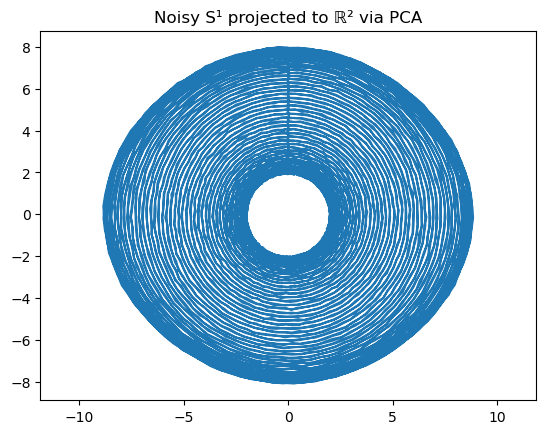

In [131]:
dataloader = dataloader.load_synthetic_ds(config)
train_loader, test_loader = dataloader

# from torch.utils.data import DataLoader
# from torch_topological.datasets import Spheres
# import torch
# 
# n_spheres = 10
# 
# # Train set
# data_set = Spheres(n_spheres=n_spheres)
# data_set = [(x[0].double(), x[1]) for x in data_set]
# 
# train_loader = DataLoader(
#     data_set,
#     batch_size=32,
#     shuffle=True,
#     drop_last=True
# )
# 
# # Test set
# data_set = Spheres(
#     train=False,
#     n_samples=2000,
#     n_spheres=n_spheres,
# )
# data_set = [(x[0].double(), x[1]) for x in data_set]
# 
# test_loader = DataLoader(
#     data_set,
#     shuffle=False,
#     batch_size=len(data_set)
# )
# 
# dataloader = train_loader, test_loader

### Model

In [132]:
model = model.EuclideanVAE(config)

### Optimizer

In [133]:
optimizer = optim.Adam(model.parameters(), lr=config.learning_rate)

### Train and evaluate model

In [134]:
history = trainer.MVAETrainer(model, dataloader, optimizer, config).train()

Trainer successfully initialized.
Training the gaussianVAE model.
Starting epoch 1/15
Epoch 1/15, Train Loss: 3.7901, Test Loss: 3.6985
--------------------------------------------------
Starting epoch 2/15
Epoch 2/15, Train Loss: 3.7923, Test Loss: 3.7583
--------------------------------------------------
Starting epoch 3/15
Epoch 3/15, Train Loss: 3.6239, Test Loss: 3.9133
--------------------------------------------------
Starting epoch 4/15
Epoch 4/15, Train Loss: 3.6440, Test Loss: 3.3604
--------------------------------------------------
Starting epoch 5/15
Epoch 5/15, Train Loss: 2.9710, Test Loss: 1.6610
--------------------------------------------------
Starting epoch 6/15
Epoch 6/15, Train Loss: 1.7821, Test Loss: 1.2776
--------------------------------------------------
Starting epoch 7/15
Epoch 7/15, Train Loss: 1.7707, Test Loss: 0.8823
--------------------------------------------------
Starting epoch 8/15
Epoch 8/15, Train Loss: 1.6634, Test Loss: 1.0683
-----------------

### Plot history

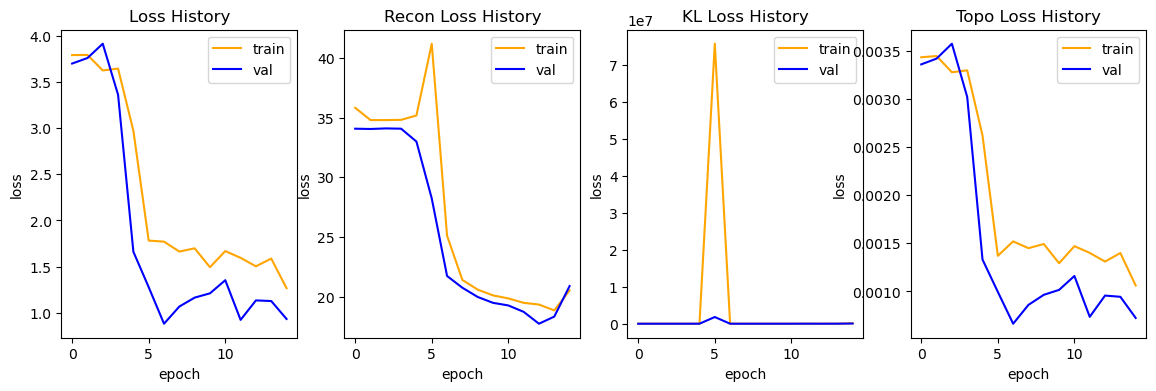

In [135]:
utils.show_training_history(history)

### Visualizing the latent space

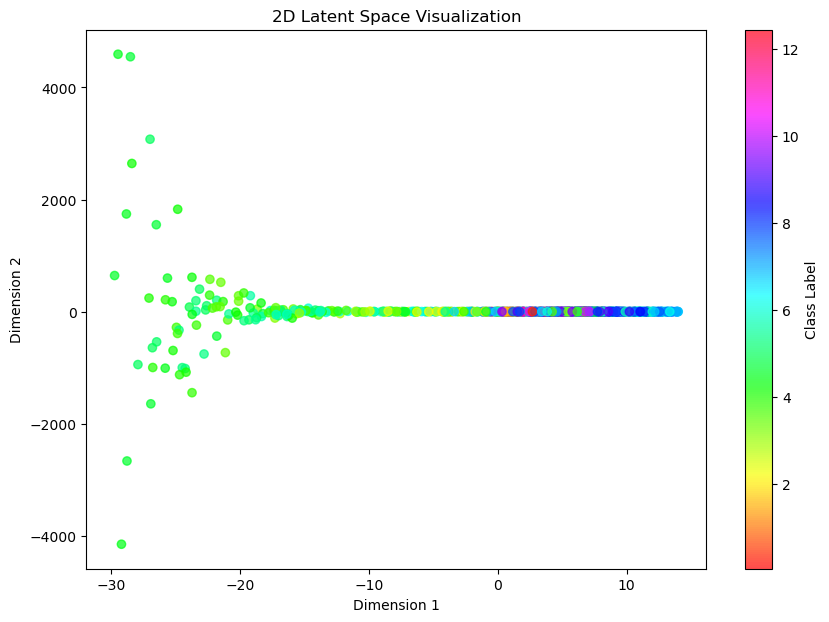

In [136]:
utils.plot_euclidean_latent_space(model, test_loader, n_samples=2000)

### Plot reconstructed manifold

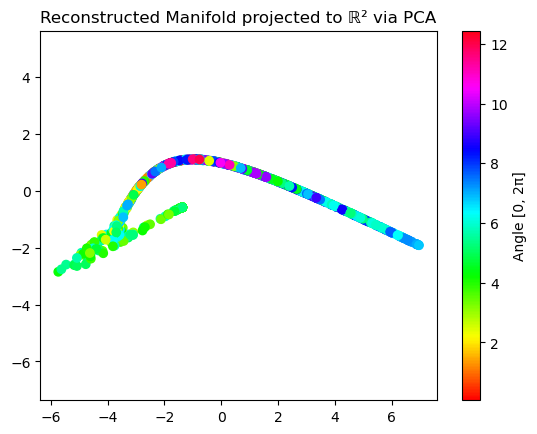

In [137]:
utils.plot_recon_manifold(model, test_loader, n_samples=2000)

### Compute curvature error

In [138]:
#utils.curvature_compute_plot_euclidean(config=config, model=model, test_loader=test_loader)